# Bitcoin Trading Bot Optimisation with WOA and PSO

## 1. Data Loading & Preprocessing

This section loads the daily data from `data/BTC-Daily.csv`, sorts it in ascending date order, and uses the `close` price as the main price series. Data before 2020-01-01 is used as the training data, while data from 2020-01-01 onward is reserved as the test data.

In [1]:
# Basic environment setup
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = PROJECT_ROOT / "data" / "BTC-Daily.csv"
SPLIT_DATE = pd.Timestamp("2020-01-01")

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Load and preprocess daily OHLCV data
required_columns = [
    "unix", "date", "symbol", "open", "high", "low", "close", "Volume BTC", "Volume USD"
]

price_data = pd.read_csv(DATA_PATH)
missing_columns = sorted(set(required_columns) - set(price_data.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

price_data = price_data[required_columns].copy()
price_data["date"] = pd.to_datetime(price_data["date"])

numeric_columns = ["open", "high", "low", "close", "Volume BTC", "Volume USD"]
for column in numeric_columns:
    price_data[column] = pd.to_numeric(price_data[column], errors="coerce")

price_data = price_data.sort_values("date").reset_index(drop=True)
price_data = price_data.drop_duplicates(subset="date", keep="last")
price_data = price_data.set_index("date")

if price_data[numeric_columns].isna().any().any():
    bad_counts = price_data[numeric_columns].isna().sum()
    raise ValueError(f"Numeric columns contain missing values:\n{bad_counts}")

close_prices = price_data["close"].astype(float)

print(f"Data loaded successfully: {DATA_PATH}")
print(f"Date range: {price_data.index.min().date()} to {price_data.index.max().date()}")
print(f"Total observations: {len(price_data)}")
print(f"Columns: {list(price_data.columns)}")

Data loaded successfully: ./data/BTC-Daily.csv
Date range: 2014-11-28 to 2022-03-01
Total observations: 2651
Columns: ['unix', 'symbol', 'open', 'high', 'low', 'close', 'Volume BTC', 'Volume USD']


This step loads the BTC daily data and standardises it into a date-sorted `close` price series.

In [3]:
# Train/test split: optimisation may only use train_data; test_data is reserved for final unseen evaluation
train_prices = close_prices[close_prices.index < SPLIT_DATE]
test_prices = close_prices[close_prices.index >= SPLIT_DATE]

train_data = train_prices.to_numpy(dtype=float)
test_data = test_prices.to_numpy(dtype=float)

if len(train_data) == 0 or len(test_data) == 0:
    raise ValueError("Train/test split produced an empty dataset.")

print(f"Training period: {train_prices.index.min().date()} to {train_prices.index.max().date()}")
print(f"Training observations: {len(train_data)} days")
print(f"Test period: {test_prices.index.min().date()} to {test_prices.index.max().date()}")
print(f"Test observations: {len(test_data)} days")
print(f"Split date: {SPLIT_DATE.date()}")

Training period: 2014-11-28 to 2019-12-31
Training observations: 1860 days
Test period: 2020-01-01 to 2022-03-01
Test observations: 791 days
Split date: 2020-01-01


This step uses 2020-01-01 as the split point. Only earlier data is used during training, while the test set is held back for the final unseen evaluation.

In [4]:
# Quick preview of the cleaned data
price_data.head()

,unix,symbol,open,high,low,close,Volume BTC,Volume USD
date,,,,,,,,
2014-11-28,1417132800,BTC/USD,363.59,381.34,360.57,376.28,3220878.18,8617.15
2014-11-29,1417219200,BTC/USD,376.42,386.60,372.25,376.72,2746157.05,7245.19
2014-11-30,1417305600,BTC/USD,376.57,381.99,373.32,373.34,1145566.61,3046.33
2014-12-01,1417392000,BTC/USD,376.40,382.31,373.03,378.39,2520662.37,6660.56
2014-12-02,1417478400,BTC/USD,378.39,382.86,375.23,379.25,2593576.46,6832.53


This preview checks a small portion of the cleaned dataset, mainly confirming that the date index, price fields, and ordering look correct.

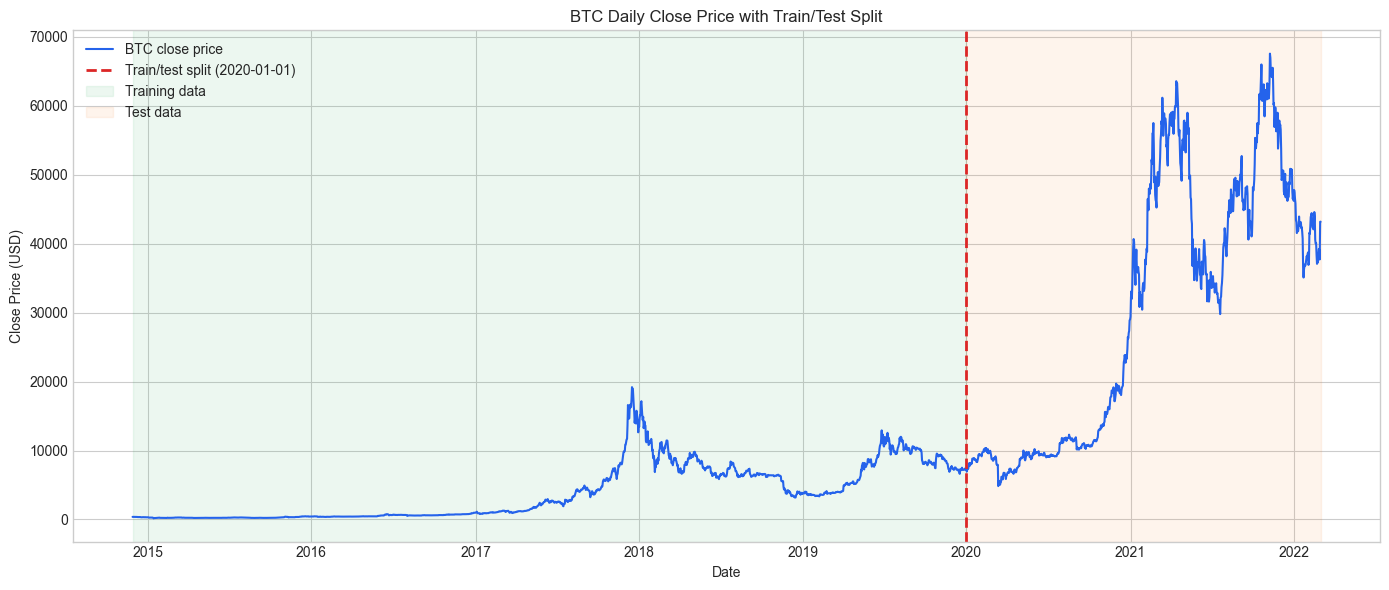

In [5]:
# Price trend visualisation: mark the train/test split point
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(price_data.index, price_data["close"], label="BTC close price", color="#2563eb", linewidth=1.5)
ax.axvline(SPLIT_DATE, color="#dc2626", linestyle="--", linewidth=2, label="Train/test split (2020-01-01)")

ax.axvspan(price_data.index.min(), SPLIT_DATE, color="#16a34a", alpha=0.08, label="Training data")
ax.axvspan(SPLIT_DATE, price_data.index.max(), color="#f97316", alpha=0.08, label="Test data")

ax.set_title("BTC Daily Close Price with Train/Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()